In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
#Loading the Dataset
df= pd.read_csv('eda.csv')

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,log_amount,Hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,5.014760,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,1.305626,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,5.939276,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,4.824306,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,4.262539,0.0


In [4]:
#Droping unnecessory columns
df=df.drop(columns = ['Time','Amount'],axis=0)

In [5]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,log_amount,Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,5.014760,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,1.305626,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,5.939276,0.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,4.824306,0.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,4.262539,0.0


### Stratified Split

In [6]:
#Spliting the data using stratify because of imbalance data
X = df.drop(columns="Class")
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,stratify=y,random_state=42)

In [7]:
X.shape

(283726, 30)

In [8]:
y.shape

(283726,)

In [9]:
# importing SMOTE 
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

### Creating LogisticRegression pipeline

In [10]:
# creating a pipeline to protect data leakage 
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

### Applying LogisticRegression

In [11]:
# training the default logistic regression 
lr_pipeline.fit(X_train,y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](30,)","['V1','V2','V3',...,'V28','log_amount','Hour']"
n_features_in_,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [12]:
# testing
lr_pred= lr_pipeline.predict(X_test)
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]

In [13]:
lr_prob

array([0.01476224, 0.01599411, 0.00788431, ..., 0.04623908, 0.03468808,
       0.01369426], shape=(56746,))

In [11]:
# model evaluation 
from sklearn.metrics import (precision_score,recall_score,f1_score,roc_auc_score,average_precision_score,confusion_matrix)

### LogisticRegression evaluation

In [15]:
lr_pred = (lr_prob >= 0.5).astype(int)

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1:",f1_score(y_test, lr_pred))

print("ROC-AUC:",roc_auc_score(y_test, lr_prob))

print("PR-AUC:",average_precision_score(y_test, lr_prob))

print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

Precision: 0.052102950408035156
Recall: 0.8736842105263158
F1: 0.09834123222748815
ROC-AUC: 0.9597001585887367
PR-AUC: 0.6824847155616152
Confusion Matrix:
[[55141  1510]
 [   12    83]]


### Creating RandomForestClassifier pipeline

In [12]:
# crating pipeline for randomforestclassifier
rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

### Applying RandomForestClassifier

In [17]:
#train the default randomforestclassifier
rf_pipeline.fit(X_train,y_train)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](30,)","['V1','V2','V3',...,'V28','log_amount','Hour']"
n_features_in_,int,30
,random_state,42
,sampling_strategy,'auto'
,k_neighbors,5


In [18]:
# testing
rf_pred=rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

### RandomForestClassifier evaluation

In [20]:
# model evaluation
lr_pred = (lr_prob >= 0.5).astype(int)

print("Precision:",precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1:",f1_score(y_test, rf_pred))

print("ROC-AUC:",roc_auc_score(y_test, rf_prob))

print("PR-AUC:",average_precision_score(y_test, rf_prob))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Precision: 0.9358974358974359
Recall: 0.7684210526315789
F1: 0.8439306358381503
ROC-AUC: 0.9549659085313679
PR-AUC: 0.8119929546495253
Confusion Matrix:
[[56646     5]
 [   22    73]]


### Creating LogisticRegression ParamGrid 

In [19]:
#creating param_grid for logistic regression
lr_param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}


### LogisticRegression hyperparameter tunning using GridSearchCV

In [20]:
# Hyperparameters tunning of logisticRegression using GridSearchCV
from sklearn.model_selection import GridSearchCV

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=2,
    verbose=1
)

lr_grid.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_di

### Creating RandomForestClassifier ParamGrid

In [13]:
#creating param_grid for RandomForestClassifier
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

### RandomForestClassifier hyperparameter tunning using GridSearchCV

In [15]:
# Hyperparameters tunning of RandomForestClassifier using GridSearchCV
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="average_precision",
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple m

In [21]:
#best parameters for both logisticRegression and RandomForestClassifier
best_lr = lr_grid.best_estimator_
best_rf = rf_grid.best_estimator_

## best model parameters after tunning
### LogisticRegression
Pipeline(steps=[('scaler', StandardScaler()), ('smote', SMOTE(random_state=42)),
                ('model',
                 LogisticRegression(C=1, max_iter=2000, random_state=42))])

### RandomForestClassifier
Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(max_features='log2', min_samples_leaf=2,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])


In [23]:
lr_prob = best_lr.predict_proba(X_test)[:, 1]
rf_prob = best_rf.predict_proba(X_test)[:, 1]

### Tunned LogisticRegression evaluation

In [27]:
# evaluation of tunned LogisticRegression
lr_pred = (lr_prob >= 0.5).astype(int)

print("Precision:",
      precision_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("F1:",
      f1_score(y_test, lr_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, lr_prob))

print("PR-AUC:",
      average_precision_score(y_test, lr_prob))

print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

Precision: 0.052102950408035156
Recall: 0.8736842105263158
F1: 0.09834123222748815
ROC-AUC: 0.9597001585887367
PR-AUC: 0.6824847155616152
Confusion Matrix:
[[55141  1510]
 [   12    83]]


### Tunned RandomForestClassifier evaluation

In [28]:
#evaluation of tunned RandomForestClassifier
rf_pred = (rf_prob >= 0.5).astype(int)

print("Precision:",
      precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1:",
      f1_score(y_test, rf_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, rf_prob))

print("PR-AUC:",
      average_precision_score(y_test, rf_prob))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Precision: 0.9125
Recall: 0.7684210526315789
F1: 0.8342857142857143
ROC-AUC: 0.9656524853465678
PR-AUC: 0.82491617925626
Confusion Matrix:
[[56644     7]
 [   22    73]]


In [13]:
trf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(max_features='log2', min_samples_leaf=2,
                                     n_estimators=200,
                                     n_jobs=-1,
                                     random_state=42))])

In [14]:
trf_pipeline.fit(X_train,y_train)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](30,)","['V1','V2','V3',...,'V28','log_amount','Hour']"
n_features_in_,int,30
,random_state,42
,sampling_strategy,'auto'
,k_neighbors,5


In [18]:
trf_pred = trf_pipeline.predict(X_test)
trf_prob = trf_pipeline.predict_proba(X_test)[:, 1]

In [25]:
#evaluation of tunned RandomForestClassifier
trf_pred = (trf_prob >= 0.5).astype(int)

print("Precision:",
      precision_score(y_test, trf_pred))

print("Recall:",
      recall_score(y_test, trf_pred))

print("F1:",
      f1_score(y_test, trf_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, trf_prob))

print("PR-AUC:",
      average_precision_score(y_test, trf_prob))

print("Confusion Matrix:")
print(confusion_matrix(y_test, trf_pred))

Precision: 0.9125
Recall: 0.7684210526315789
F1: 0.8342857142857143
ROC-AUC: 0.9656522995366829
PR-AUC: 0.8249161477759035
Confusion Matrix:
[[56644     7]
 [   22    73]]


### changing the thresholds to 0.6

In [26]:
#evaluation of tunned RandomForestClassifier
trf_pred = (trf_prob >= 0.6).astype(int)

print("Precision:",
      precision_score(y_test, trf_pred))

print("Recall:",
      recall_score(y_test, trf_pred))

print("F1:",
      f1_score(y_test, trf_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, trf_prob))

print("PR-AUC:",
      average_precision_score(y_test, trf_prob))

print("Confusion Matrix:")
print(confusion_matrix(y_test, trf_pred))

Precision: 0.972972972972973
Recall: 0.7578947368421053
F1: 0.8520710059171598
ROC-AUC: 0.9656522995366829
PR-AUC: 0.8249161477759035
Confusion Matrix:
[[56649     2]
 [   23    72]]


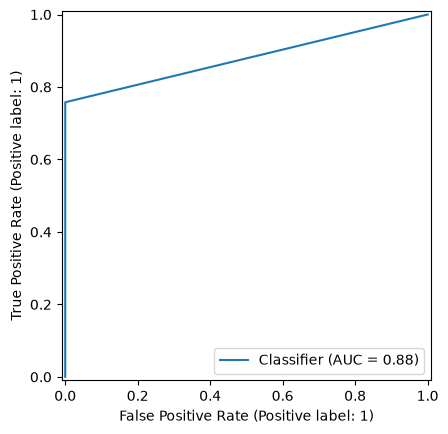

In [24]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, trf_pred)

### Saving the model using joblib

In [29]:
import joblib

joblib.dump(trf_pipeline, 'fraud_detection_model.pkl',compress=3)

['fraud_detection_model.pkl']

# Report
- Remove the unnecessory columns (Time,Amount)
- Split the data usng stratified train_test_split
- Applying LogisticRegression with SMOTE
- Evaluate using Precision,Recall,ROC_AUC,F1 and Average_precision
- Same for RandomForestClassifier
- Tunned the LogisticRegression and RandomForestClassifier using GridSearchCV
- The Tunned RandomForestClassifier give better result using 0.6 threshold
- The final model for selection is Tunned RandomForestClassifier
- Save the model using Joblib
- Among the evaluated models, the tuned Random Forest achieved the best overall performance for fraud detection, obtaining a ROC-AUC of 0.9657 and PR-AUC of 0.8249, with 91.25% precision and 76.84% recall. Although Logistic Regression achieved higher recall (87.37%), its precision was only 5.21%, resulting in a substantially larger number of false-positive fraud alerts. Therefore, Random Forest provides a more practical balance between detecting fraudulent transactions and minimizing false alarms.